In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [14]:
#Folder for graphs/fiugures
Path("figures").mkdir(parents=True, exist_ok=True)

In [15]:
path = "data/df_global_oil_"

df_inventories = pd.read_csv(path + "inventories_clean.csv")
df_withdraws = pd.read_csv(path + "withdraws_clean.csv")

In [16]:
#Verify data loaded properly
df_inventories.head()

,Date,OECD total,United States,Other OECD
0,2022-01-01,2647.601850,1190.102850,1457.499
1,2022-02-01,2619.752228,1165.614228,1454.138
2,2022-03-01,2605.418099,1154.238099,1451.180
3,2022-04-01,2656.759189,1153.830189,1502.929
4,2022-05-01,2668.669406,1172.156406,1496.513


In [17]:
df_withdraws.head()

,Date,World Total,USA,OECD,Other Inventory draws and balance
0,2022-01-01,-0.961946,0.447567,-0.416742,-0.992771
1,2022-02-01,1.094635,1.211915,0.120036,-0.237315
2,2022-03-01,-0.646688,0.780230,0.095419,-1.522338
3,2022-04-01,-1.355114,0.620097,-1.724967,-0.250244
4,2022-05-01,-0.048192,0.207445,0.206968,-0.462605


In [18]:
#Convert to datetime so axis is properly spaced
df_withdraws['Date'] = pd.to_datetime(df_withdraws['Date'])
df_inventories['Date'] = pd.to_datetime(df_inventories['Date'])

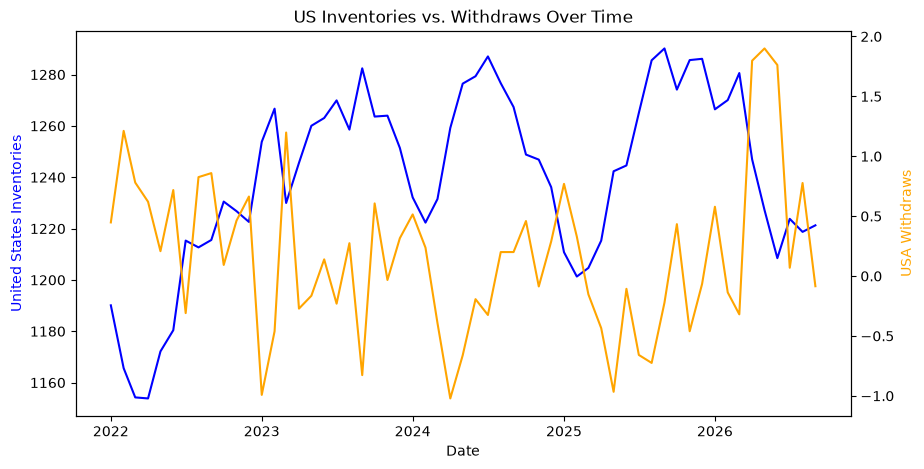

<Figure size 640x480 with 0 Axes>

In [19]:
#Plot USA wiithdraws vs inventories using dual y-axis
fig, ax1 = plt.subplots(figsize=(10,5))

ax1.plot(
    df_inventories['Date'],
    df_inventories['United States'],
    color='blue',
    label = 'Inventories'
)


ax1.set_xlabel('Date')
ax1.set_ylabel('United States Inventories', color='blue')

ax2 = ax1.twinx()
ax2.plot(
    df_withdraws['Date'],
    df_withdraws['USA'],
    color = 'orange',
    label = 'Withdraws'
)

ax2.set_ylabel('USA Withdraws', color='orange')

plt.title('US Inventories vs. Withdraws Over Time')
plt.show()

plt.savefig('figures/usa_inventory_vs_draws.png', dpi=300)

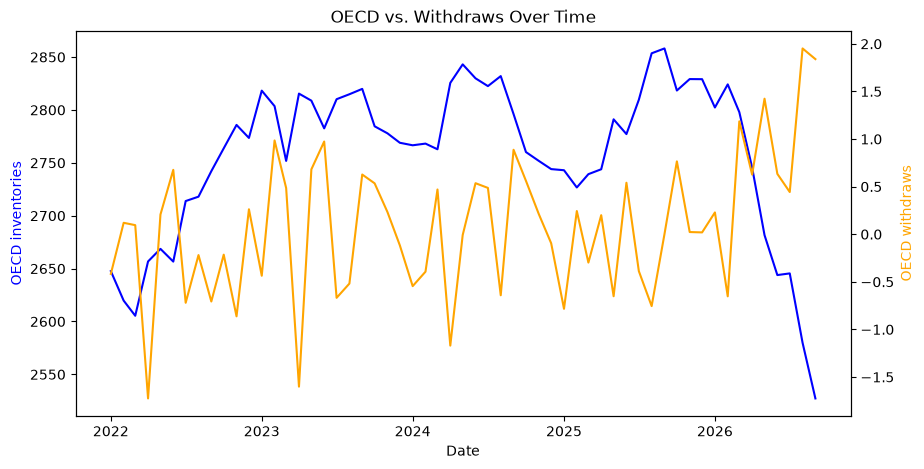

<Figure size 640x480 with 0 Axes>

In [20]:
#Plot OECD withdrwas vs inventories (same process as before)
fig, ax1 = plt.subplots(figsize=(10,5))

ax1.plot(
    df_inventories['Date'],
    df_inventories['OECD total'],
    color='blue',
    label='inventories'
)

ax1.set_xlabel('Date')
ax1.set_ylabel("OECD inventories", color='blue')

ax2 = ax1.twinx()
ax2.plot(
    df_withdraws['Date'],
    df_withdraws['OECD'],
    color='orange',
    label='withdraws'
)
ax2.set_ylabel("OECD withdraws", color='orange')
plt.title('OECD vs. Withdraws Over Time')
plt.show()

plt.savefig('figures/oecd_inventory_vs_draws.png', dpi=300)

In [22]:
df_inventories['US_3M_Avg'] = df_inventories['United States'].rolling(window=3).mean()
df_inventories['OECD_3M_Avg'] = df_inventories['OECD total'].rolling(window=3).mean()
df_inventories['US_MoM_Pct'] = df_inventories['United States'].pct_change() * 100
df_inventories['OECD_MoM_Pct'] = df_inventories['OECD total'].pct_change() * 100

In [23]:
df_inventories.head()

,Date,OECD total,United States,Other OECD,US_3M_Avg,OECD_3M_Avg,US_MoM_Pct,OECD_MoM_Pct
0,2022-01-01,2647.601850,1190.102850,1457.499,NaN,NaN,NaN,NaN
1,2022-02-01,2619.752228,1165.614228,1454.138,NaN,NaN,-2.057690,-1.051881
2,2022-03-01,2605.418099,1154.238099,1451.180,1169.985059,2624.257392,-0.975977,-0.547156
3,2022-04-01,2656.759189,1153.830189,1502.929,1157.894172,2627.309839,-0.035340,1.970551
4,2022-05-01,2668.669406,1172.156406,1496.513,1160.074898,2643.615565,1.588294,0.448299
